# Trace causal chains to explain unexpected behaviors ## bridging concepts 

In [1]:
import numpy as np
import pandas as pd
from fcmpy import FcmSimulator

# -------------------------------
# File paths
# -------------------------------
matrix_path = "Experiments/Final Modified_Matrix-Copy1.csv"
initial_values_path = "Experiments/initial values.csv"
labels_path = "Original Data/Concept labels.csv"

# -------------------------------
# Load FCM data
# -------------------------------
fcm_data = pd.read_csv(matrix_path, index_col=0)
concept_ids = fcm_data.columns.tolist()
weight_matrix = fcm_data.astype(float).values

labels_df = pd.read_csv(labels_path)
concept_label_map = dict(zip(labels_df['Concept ID'], labels_df['Label']))
concept_labels = [concept_label_map.get(cid, cid) for cid in concept_ids]

# -------------------------------
# Load initial values
# -------------------------------
def get_initial_values():
    df = pd.read_csv(initial_values_path)
    return {
        concept_label_map.get(concept, concept): df.loc[df['Concept ID'] == concept, 'Initial Value'].values[0]
        if concept in df['Concept ID'].values else 0.0
        for concept in concept_ids
    }

init_state = get_initial_values()

# -------------------------------
# Set inactive concepts to zero influence
# -------------------------------
inactive_concepts = [c for c, val in init_state.items() if val == 0.0]
for concept in inactive_concepts:
    idx = concept_labels.index(concept)
    weight_matrix[:, idx] = 0  # remove incoming
    weight_matrix[idx, :] = 0  # remove outgoing

# -------------------------------
# Run FCM simulation
# -------------------------------
sim = FcmSimulator()
result = sim.simulate(
    initial_state=init_state,
    weight_matrix=weight_matrix,
    transfer='sigmoid',
    inference='kosko',
    thresh=0.001,
    iterations=20,
    l=1
)
results_df = pd.DataFrame(result, columns=concept_labels)
print("Simulation complete!")

# -------------------------------
# Trace bridge concepts between C15 and C40
# -------------------------------
def trace_paths(source_id, target_id, path=None, paths=None):
    if path is None:
        path = []
    if paths is None:
        paths = []

    source_label = concept_label_map[source_id]
    target_label = concept_label_map[target_id]

    path = path + [source_label]

    if source_label == target_label:
        paths.append(path)
        return paths

    idx = concept_labels.index(source_label)
    outgoing = fcm_data.iloc[idx, :]
    outgoing_nonzero = outgoing[outgoing != 0]

    for child_id in outgoing_nonzero.index:
        child_label = concept_label_map.get(child_id, child_id)
        if child_label not in path:  # avoid cycles
            trace_paths(child_id, target_id, path, paths)
    return paths

# Trace paths from C15 to C40
paths_c15_to_c40 = trace_paths("C15", "C40")
bridge_concepts = set()
for p in paths_c15_to_c40:
    bridge_concepts.update(p[1:-1])  # exclude source and target

print("\nBridge concepts between C15 (Flooding) and C40 (Tourism):")
for concept in bridge_concepts:
    print("-", concept)

print("\nFinal activation values of bridge concepts:")
for concept in bridge_concepts:
    print(f"{concept}: {results_df[concept].iloc[-1]:.3f}")


The values converged in the 5 state (e <= 0.001)
Simulation complete!

Bridge concepts between C15 (Flooding) and C40 (Tourism):
- Abandonment
- Preservation 
-  landscape
- Con & Res
- Usage 
- Monitoring 
- Stray animals
- OUV
- Phy-Fab
- Accessibility
- US
- LA
- MP
- Erosion
- ComV
- Sustainability
- Budget

Final activation values of bridge concepts:
Abandonment: 0.000
Preservation : 0.000
 landscape: 0.425
Con & Res: 0.000
Usage : 0.000
Monitoring : 0.404
Stray animals: 0.000
OUV: 0.700
Phy-Fab: 0.422
Accessibility: 0.200
US: 0.000
LA: 0.421
MP: 0.637
Erosion: 0.548
ComV: 0.200
Sustainability: 0.000
Budget: 0.503


/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \


## Causal Tracing and Fuzzy Causal Algebra from Food to Tourism and Tourism to Flood

/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \


The values converged in the 5 state (e <= 0.001)
✅ FCM Simulation complete!
Final concept activations:
   Pro-Mit  Monitoring   Con & Res    Budget       OUV  Unfenced    OGE  \
4      0.0     0.404319        0.0  0.503125  0.700012        1.0  0.25   

   Usage   Preservation   Flooding  ...  Temperature        LA   HR    TF  \
4     0.0            0.0       0.0  ...          0.1  0.421038  0.1  0.25   

    Phy-Fab        MP  Material type  Conflict    NGV  Stray animals  
4  0.422308  0.637031            0.5        0.5  0.25            0.0  

[1 rows x 35 columns]

Paths from C15 → C40:
Flooding ->  landscape -> OUV -> Tourism
Flooding -> Tourism
Flooding -> Erosion -> Phy-Fab -> OUV -> Tourism
Flooding -> Accessibility -> Con & Res -> Preservation  -> Budget -> Sustainability -> OUV -> Tourism
Flooding -> Accessibility -> Con & Res -> Preservation  ->  landscape -> OUV -> Tourism
Flooding -> Accessibility -> Con & Res -> Preservation  -> Sustainability -> OUV -> Tourism
Flooding ->

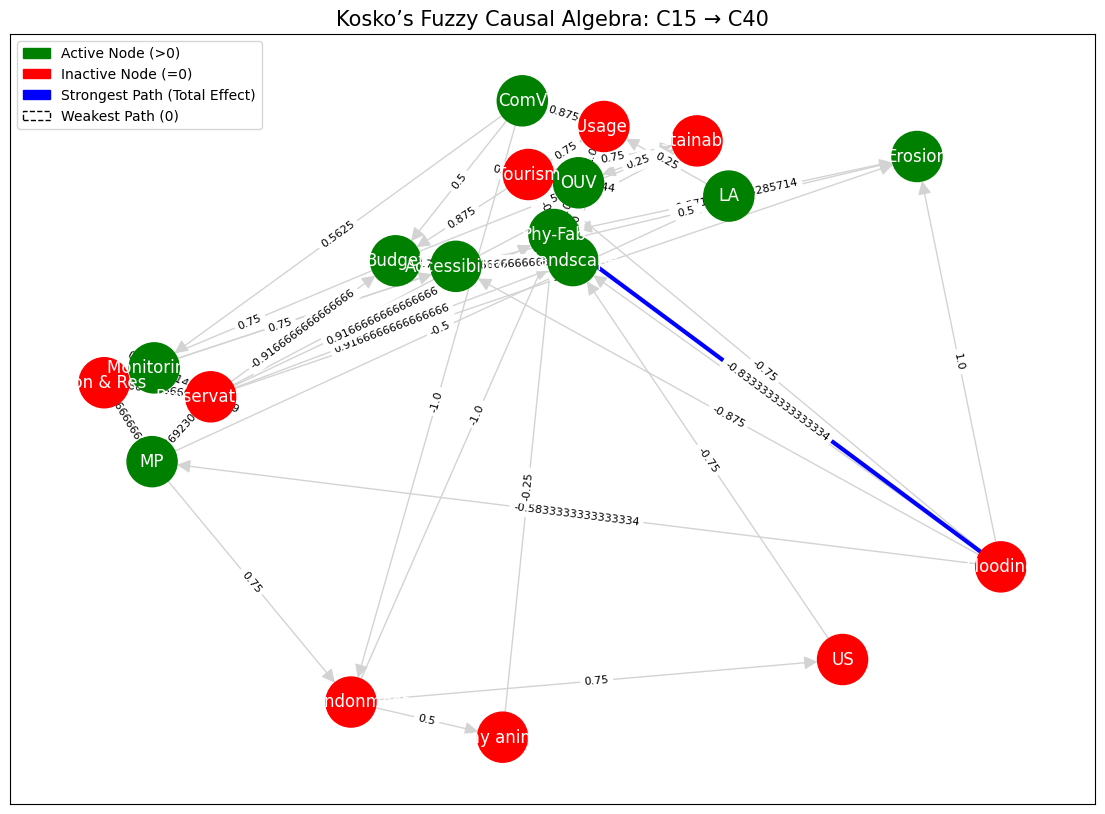


Paths from C40 → C15:

=== Kosko's Fuzzy Causal Algebra (C40 → C15) ===

Total Effect (max weakest-link): 0.000
No paths found.


In [6]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from fcmpy import FcmSimulator
import matplotlib.patches as mpatches

# =====================================================
# 1. Load Data
# =====================================================
matrix_path = "Experiments/Final Modified_Matrix-Copy1.csv"
initial_values_path = "Experiments/initial values.csv"
labels_path = "Original Data/Concept labels.csv"

# Load matrix and labels
fcm_data = pd.read_csv(matrix_path, index_col=0)
concept_ids = fcm_data.columns.tolist()
weight_matrix = fcm_data.astype(float).values

labels_df = pd.read_csv(labels_path)
concept_label_map = dict(zip(labels_df['Concept ID'], labels_df['Label']))
concept_labels = [concept_label_map.get(cid, cid) for cid in concept_ids]

# Load initial values
def get_initial_values():
    df = pd.read_csv(initial_values_path)
    return {
        concept_label_map.get(concept, concept): df.loc[df['Concept ID'] == concept, 'Initial Value'].values[0]
        if concept in df['Concept ID'].values else 0.0
        for concept in concept_ids
    }

init_state = get_initial_values()

# =====================================================
# 2. Handle Inactive Concepts (set influence = 0)
# =====================================================
inactive_concepts = [c for c, val in init_state.items() if val == 0.0]
for concept in inactive_concepts:
    idx = concept_labels.index(concept)
    weight_matrix[:, idx] = 0  # remove incoming
    weight_matrix[idx, :] = 0  # remove outgoing

# =====================================================
# 3. Run FCM Simulation
# =====================================================
sim = FcmSimulator()
result = sim.simulate(
    initial_state=init_state,
    weight_matrix=weight_matrix,
    transfer='sigmoid',
    inference='kosko',
    thresh=0.001,
    iterations=20,
    l=1
)
results_df = pd.DataFrame(result, columns=concept_labels)
final_values = results_df.iloc[-1].to_dict()

print("✅ FCM Simulation complete!")
print("Final concept activations:")
print(results_df.tail(1))

# =====================================================
# 4. Build Graph
# =====================================================
G = nx.DiGraph()
G.add_nodes_from(concept_labels)
for i, src in enumerate(concept_ids):
    for j, tgt in enumerate(concept_ids):
        weight = fcm_data.iloc[i, j]
        if weight != 0:
            G.add_edge(concept_label_map[src], concept_label_map[tgt], weight=weight)

# Assign final activations as node attributes
nx.set_node_attributes(G, final_values, "activation")

# =====================================================
# 5. Trace Influence Paths
# =====================================================
def trace_influence_chain(G, source_id, target_id):
    """
    Trace all possible paths between source and target.
    source_id, target_id: concept IDs (e.g., 'C15', 'C40')
    """
    source_label = concept_label_map.get(source_id, source_id)
    target_label = concept_label_map.get(target_id, target_id)
    try:
        return list(nx.all_simple_paths(G, source=source_label, target=target_label))
    except nx.NetworkXNoPath:
        return []

# =====================================================
# 6. Kosko’s Fuzzy Causal Algebra: Weakest-Link per Path & Total Effect
# =====================================================
def compute_weakest_link_per_path(G, paths):
    """
    Compute weakest (minimum absolute) edge weight for each path.
    """
    path_effects = {}
    for p in paths:
        weights = []
        for i in range(len(p) - 1):
            w = G[p[i]][p[i+1]]["weight"]
            weights.append(abs(w))
        path_effects[tuple(p)] = min(weights) if weights else 0
    return path_effects

def compute_total_effect(path_effects):
    """
    Kosko's total effect = maximum weakest-link across all paths.
    """
    if not path_effects:
        return 0
    return max(path_effects.values())

# =====================================================
# 7. Visualization for Kosko Paths
# =====================================================
def visualize_chain(
    G, paths, title="Influence Chain Visualization", fixed_pos_path=None
):
    if not paths:
        print("No paths found.")
        return

    # Collect subgraph nodes
    sub_nodes = set()
    for p in paths:
        sub_nodes.update(p)
    subgraph = G.subgraph(sub_nodes).copy()

    # Node activation values
    node_colors = [
        "green" if subgraph.nodes[n].get("activation", 0) > 0 else "red"
        for n in subgraph.nodes
    ]

    # Edge labels
    edge_labels = nx.get_edge_attributes(subgraph, "weight")

    # --- Layout control ---
    # Use fixed layout if saved before (ensures identical structure)
    if fixed_pos_path and os.path.exists(fixed_pos_path):
        pos = np.load(fixed_pos_path, allow_pickle=True).item()
    else:
        # kamada_kawai_layout spreads nodes more evenly
        pos = nx.kamada_kawai_layout(subgraph)
        # optionally save layout
        if fixed_pos_path:
            np.save(fixed_pos_path, pos)

    plt.figure(figsize=(12, 8))

    # Draw base network
    nx.draw_networkx_nodes(
        subgraph, pos,
        node_color=node_colors,
        node_size=1800,
        alpha=0.9
    )
    nx.draw_networkx_labels(
        subgraph, pos,
        font_size=10,
        font_color="white",
        font_weight="bold"
    )

    # Draw edges
    edge_weights = [abs(d['weight']) for _, _, d in subgraph.edges(data=True)]
    nx.draw_networkx_edges(
        subgraph, pos,
        arrows=True,
        arrowstyle='-|>',
        arrowsize=18,
        width=edge_weights,
        edge_color='lightgray'
    )

    # Add edge labels
    nx.draw_networkx_edge_labels(
        subgraph, pos,
        edge_labels=edge_labels,
        font_size=8
    )

    # Highlight strongest & weakest paths
    if paths:
        # Compute weakest and strongest link per path
        for p in paths:
            weights = [
                subgraph[u][v]["weight"] for u, v in zip(p[:-1], p[1:]) if (u, v) in subgraph.edges
            ]
            if weights:
                weakest_link = min(weights, key=abs)
                strongest_link = max(weights, key=abs)

                for u, v in zip(p[:-1], p[1:]):
                    if subgraph[u][v]["weight"] == weakest_link:
                        nx.draw_networkx_edges(
                            subgraph, pos, edgelist=[(u, v)],
                            edge_color="black", style="dashed", width=2,
                            label="Weakest Path (0)"
                        )
                    if subgraph[u][v]["weight"] == strongest_link:
                        nx.draw_networkx_edges(
                            subgraph, pos, edgelist=[(u, v)],
                            edge_color="blue", width=3,
                            label="Strongest Path (Total Effect)"
                        )

    # Legend
    import matplotlib.patches as mpatches
    active_patch = mpatches.Patch(color='green', label='Active Node (>0)')
    inactive_patch = mpatches.Patch(color='red', label='Inactive Node (=0)')
    strong_patch = mpatches.Patch(color='blue', label='Strongest Path (Total Effect)')
    weak_patch = mpatches.Patch(
        facecolor='none', edgecolor='black', linestyle='--', label='Weakest Path (0)'
    )
    plt.legend(
        handles=[active_patch, inactive_patch, strong_patch, weak_patch],
        loc='upper left', fontsize=9, frameon=True
    )

    plt.title(title, fontsize=14)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


# =====================================================
# 8. Example Usage: Trace C15 → C40
# =====================================================
source_id = "C15"
target_id = "C40"

paths_c15_to_c40 = trace_influence_chain(G, source_id, target_id)
print(f"\nPaths from {source_id} → {target_id}:")
for p in paths_c15_to_c40:
    print(" -> ".join(p))

# Compute weakest-link and total effect
path_effects_c15_to_c40 = compute_weakest_link_per_path(G, paths_c15_to_c40)
total_effect_c15_to_c40 = compute_total_effect(path_effects_c15_to_c40)

print(f"\n=== Kosko's Fuzzy Causal Algebra ({source_id} → {target_id}) ===")
for p, eff in path_effects_c15_to_c40.items():
    print(" -> ".join(p), f"| Weakest link = {eff:.3f}")
print(f"\nTotal Effect (max weakest-link): {total_effect_c15_to_c40:.3f}")

# Visualize results
visualize_kosko_paths(G, path_effects_c15_to_c40, title=f"Kosko’s Fuzzy Causal Algebra: {source_id} → {target_id}")

# =====================================================
# 9. (Optional) Reverse Direction
# =====================================================
source_id_rev = target_id
target_id_rev = source_id

paths_c40_to_c15 = trace_influence_chain(G, source_id_rev, target_id_rev)
print(f"\nPaths from {source_id_rev} → {target_id_rev}:")
for p in paths_c40_to_c15:
    print(" -> ".join(p))

path_effects_c40_to_c15 = compute_weakest_link_per_path(G, paths_c40_to_c15)
total_effect_c40_to_c15 = compute_total_effect(path_effects_c40_to_c15)

print(f"\n=== Kosko's Fuzzy Causal Algebra ({source_id_rev} → {target_id_rev}) ===")
for p, eff in path_effects_c40_to_c15.items():
    print(" -> ".join(p), f"| Weakest link = {eff:.3f}")
print(f"\nTotal Effect (max weakest-link): {total_effect_c40_to_c15:.3f}")

visualize_kosko_paths(G, path_effects_c40_to_c15, title=f"Kosko’s Fuzzy Causal Algebra: {source_id_rev} → {target_id_rev}")


### Defining the state of concepts in the pathway

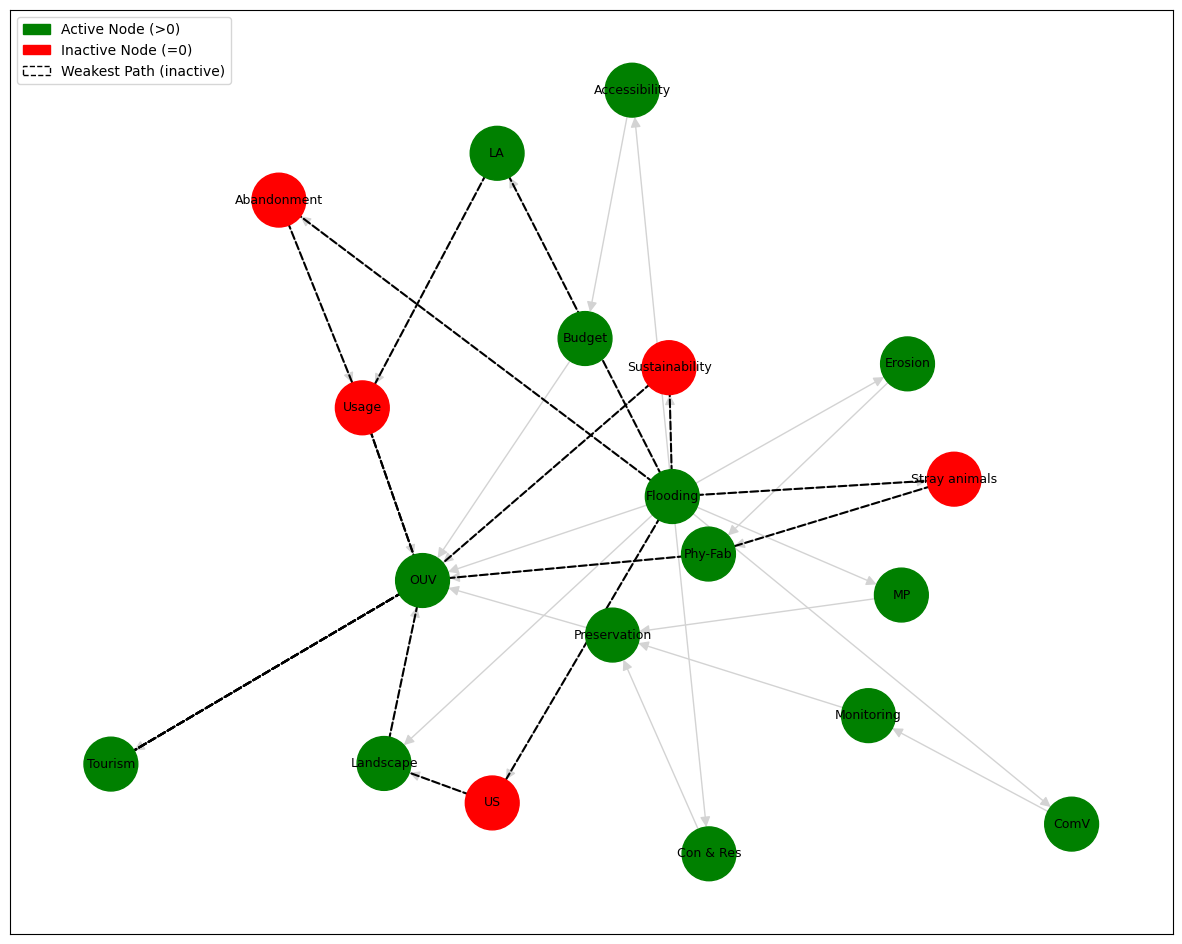

In [57]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.patches as mpatches

# -------------------------------
# Bridge concepts with activation values
# -------------------------------
bridge_concepts = {
    "LA": 0.421,
    "OUV": 0.700,
    "Abandonment": 0.000,
    "Accessibility": 0.200,
    "Erosion": 0.548,
    "Landscape": 0.425,
    "Preservation": 0.25,
    "MP": 0.637,
    "Monitoring": 0.404,
    "Stray animals": 0.000,
    "US": 0.000,
    "ComV": 0.200,
    "Sustainability": 0.000,
    "Phy-Fab": 0.422,
    "Con & Res": 0.25,
    "Budget": 0.503,
    "Usage": 0.000
}

# -------------------------------
# Define edges (simplified paths Flooding -> Tourism)
# -------------------------------
edges = [
    ("Flooding", "OUV"), ("OUV", "Tourism"),
    ("Flooding", "Accessibility"), ("Accessibility", "Budget"), ("Budget", "OUV"),
    ("Flooding", "Erosion"), ("Erosion", "Phy-Fab"), ("Phy-Fab", "OUV"),
    ("Flooding", "Landscape"), ("Landscape", "OUV"),
    ("Flooding", "MP"), ("MP", "Preservation"), ("Preservation", "OUV"),
    ("Flooding", "LA"), ("LA", "Usage"), ("Usage", "OUV"),
    ("Flooding", "Abandonment"), ("Abandonment", "Usage"),
    ("Flooding", "ComV"), ("ComV", "Monitoring"), ("Monitoring", "Preservation"),
    ("Flooding", "Stray animals"), ("Stray animals", "Phy-Fab"),
    ("Flooding", "US"), ("US", "Landscape"),
    ("Flooding", "Sustainability"), ("Sustainability", "OUV"),
    ("Flooding", "Con & Res"), ("Con & Res", "Preservation"),
]

# -------------------------------
# Build graph
# -------------------------------
G = nx.DiGraph()
G.add_edges_from(edges)

# Add activations
for node, activation in bridge_concepts.items():
    if node in G.nodes:
        G.nodes[node]["activation"] = activation

# Add Flooding and Tourism as source/target
G.add_node("Flooding", activation=1.0)
G.add_node("Tourism", activation=0.8)

# -------------------------------
# Compute weakest-link per path
# -------------------------------
def compute_weakest_link(G, path):
    weights = []
    for i in range(len(path) - 1):
        src, tgt = path[i], path[i+1]
        w = G.nodes[tgt].get("activation", 0)
        weights.append(w)
    return min(weights) if weights else 0

paths = list(nx.all_simple_paths(G, source="Flooding", target="Tourism"))
path_effects = {tuple(p): compute_weakest_link(G, p) for p in paths}
strongest_path = max(path_effects, key=path_effects.get)
weakest_paths = [p for p, eff in path_effects.items() if eff == 0]

# -------------------------------
# Visualization
# -------------------------------
pos = nx.spring_layout(G, seed=42)

# Node colors
node_colors = ["green" if G.nodes[n].get("activation", 0) > 0 else "red" for n in G.nodes]

plt.figure(figsize=(15, 12))
nx.draw_networkx(
    G, pos,
    with_labels=True,
    node_color=node_colors,
    node_size=1500,
    font_size=9,
    font_color="black",
    arrows=True,
    arrowsize=15,
    edge_color="lightgray"  # all edges in light gray
)

# Weakest paths (score=0) in dashed black
for wp in weakest_paths:
    weak_edges = [(wp[i], wp[i+1]) for i in range(len(wp)-1)]
    nx.draw_networkx_edges(G, pos, edgelist=weak_edges, edge_color="black", style="dashed", width=1.5)

# Remove edge labels
# (nothing drawn)

# -------------------------------
# Legend
# -------------------------------
active_patch = mpatches.Patch(color="green", label="Active Node (>0)")
inactive_patch = mpatches.Patch(color="red", label="Inactive Node (=0)")
weak_patch = mpatches.Patch(edgecolor="black", facecolor="none", linestyle="--", label="Weakest Path (inactive)")

plt.legend(handles=[active_patch, inactive_patch, weak_patch], loc="upper left")
plt.title("", fontsize=14)


# -------------------------------
# Save figure
# -------------------------------
output_folder = "Analysis and output folders"
os.makedirs(output_folder, exist_ok=True)
output_path = os.path.join(output_folder, "Flooding_to_Tourism.png")
plt.savefig(output_path, dpi=600, bbox_inches="tight")  # High-quality save
plt.show()



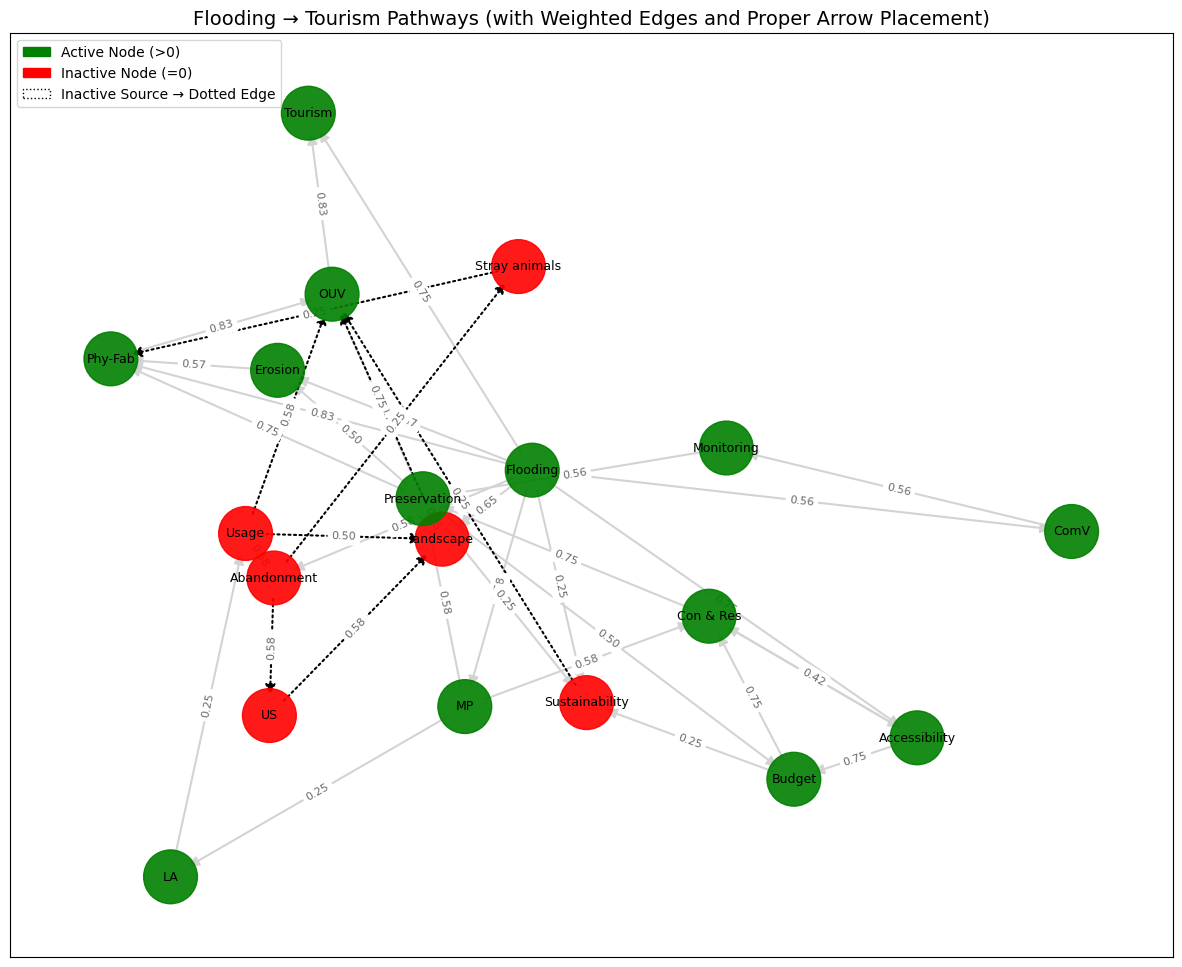

In [2]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.patches as mpatches
import os

# -------------------------------
# Bridge concepts with activation values
# -------------------------------
bridge_concepts = {
    "LA": 0.421,
    "OUV": 0.700,
    "Abandonment": 0.000,
    "Accessibility": 0.200,
    "Erosion": 0.548,
    "Landscape": 0.425,
    "Preservation": 0.25,
    "MP": 0.637,
    "Monitoring": 0.404,
    "Stray animals": 0.000,
    "US": 0.000,
    "ComV": 0.200,
    "Sustainability": 0.000,
    "Phy-Fab": 0.422,
    "Con & Res": 0.25,
    "Budget": 0.503,
    "Usage": 0.000
}

# -------------------------------
# Define weighted edges (unique edges with maximum weights)
# -------------------------------
edges = [
    ("Flooding", "landscape", 0.65),
    ("landscape", "OUV", 0.75),
    ("OUV", "Tourism", 0.833),
    ("Flooding", "Tourism", 0.75),
    ("Flooding", "Erosion", 0.571),
    ("Erosion", "Phy-Fab", 0.571),
    ("Phy-Fab", "OUV", 0.833),
    ("Flooding", "Accessibility", 0.75),
    ("Accessibility", "Con & Res", 0.75),
    ("Con & Res", "Preservation", 0.75),
    ("Preservation", "Budget", 0.5),
    ("Budget", "Sustainability", 0.25),
    ("Sustainability", "OUV", 0.25),
    ("Preservation", "landscape", 0.75),
    ("Preservation", "Sustainability", 0.25),
    ("Preservation", "Erosion", 0.5),
    ("Preservation", "Phy-Fab", 0.75),
    ("Accessibility", "Budget", 0.75),
    ("Flooding", "Phy-Fab", 0.833),
    ("Flooding", "MP", 0.583),
    ("MP", "Con & Res", 0.583),
    ("MP", "Preservation", 0.583),
    ("Preservation", "OUV", 0.75),
    ("Flooding", "Abandonment", 0.583),
    ("Abandonment", "Usage", 0.583),
    ("Usage", "OUV", 0.583),
    ("Usage", "landscape", 0.5),
    ("ComV", "Monitoring", 0.562),
    ("Monitoring", "Preservation", 0.562),
    ("Budget", "Con & Res", 0.75),
    ("Con & Res", "Accessibility", 0.417),
    ("Abandonment", "US", 0.583),
    ("US", "landscape", 0.583),
    ("Abandonment", "Stray animals", 0.25),
    ("Stray animals", "Phy-Fab", 0.25),
    ("MP", "LA", 0.25),
    ("LA", "Usage", 0.25),
    ("Flooding", "ComV", 0.562),
    ("Flooding", "Sustainability", 0.25)
]

# -------------------------------
# Build directed graph
# -------------------------------
G = nx.DiGraph()
for src, tgt, w in edges:
    G.add_edge(src, tgt, weight=w)

# Add activations
for node, activation in bridge_concepts.items():
    if node in G.nodes:
        G.nodes[node]["activation"] = activation

# Add Flooding and Tourism as key nodes
G.add_node("Flooding", activation=1.0)
G.add_node("Tourism", activation=0.8)

# -------------------------------
# Layout and node color
# -------------------------------
pos = nx.spring_layout(G, seed=42)
node_colors = ["green" if G.nodes[n].get("activation", 0) > 0 else "red" for n in G.nodes]

# -------------------------------
# Prepare edge styles
# -------------------------------
active_edges = []
inactive_edges = []
edge_labels = {}

for u, v, data in G.edges(data=True):
    weight = data.get("weight", 0)
    edge_labels[(u, v)] = f"{weight:.2f}"
    if G.nodes[u].get("activation", 0) == 0:
        inactive_edges.append((u, v))
    else:
        active_edges.append((u, v))

# -------------------------------
# Draw the improved network
# -------------------------------
plt.figure(figsize=(15, 12))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1500, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=9, font_color="black")

# Active edges (solid light gray)
nx.draw_networkx_edges(
    G, pos,
    edgelist=active_edges,
    edge_color="lightgray",
    arrows=True,
    arrowsize=15,
    width=1.5,
    connectionstyle="arc3,rad=0",
    min_source_margin=15,
    min_target_margin=15
)

# Inactive-source edges (black dotted)
nx.draw_networkx_edges(
    G, pos,
    edgelist=inactive_edges,
    edge_color="black",
    style="dotted",
    arrows=True,
    arrowsize=15,
    width=1.5,
    connectionstyle="arc3,rad=0",
    min_source_margin=15,
    min_target_margin=15
)

# Edge labels (weights)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, font_color="dimgray")

# -------------------------------
# Legend
# -------------------------------
active_patch = mpatches.Patch(color="green", label="Active Node (>0)")
inactive_patch = mpatches.Patch(color="red", label="Inactive Node (=0)")
inactive_edge_patch = mpatches.Patch(edgecolor="black", facecolor="none", linestyle=":", label="Inactive Source → Dotted Edge")

plt.legend(handles=[active_patch, inactive_patch, inactive_edge_patch], loc="upper left")
plt.title("Flooding → Tourism Pathways (with Weighted Edges and Proper Arrow Placement)", fontsize=14)

# -------------------------------
# Save and show
# -------------------------------
output_folder = "Analysis and output folders"
os.makedirs(output_folder, exist_ok=True)
output_path = os.path.join(output_folder, "Flooding_to_Tourism_arrow_adjusted.png")
plt.savefig(output_path, dpi=600, bbox_inches="tight")
plt.show()


#### Enhancing visualization

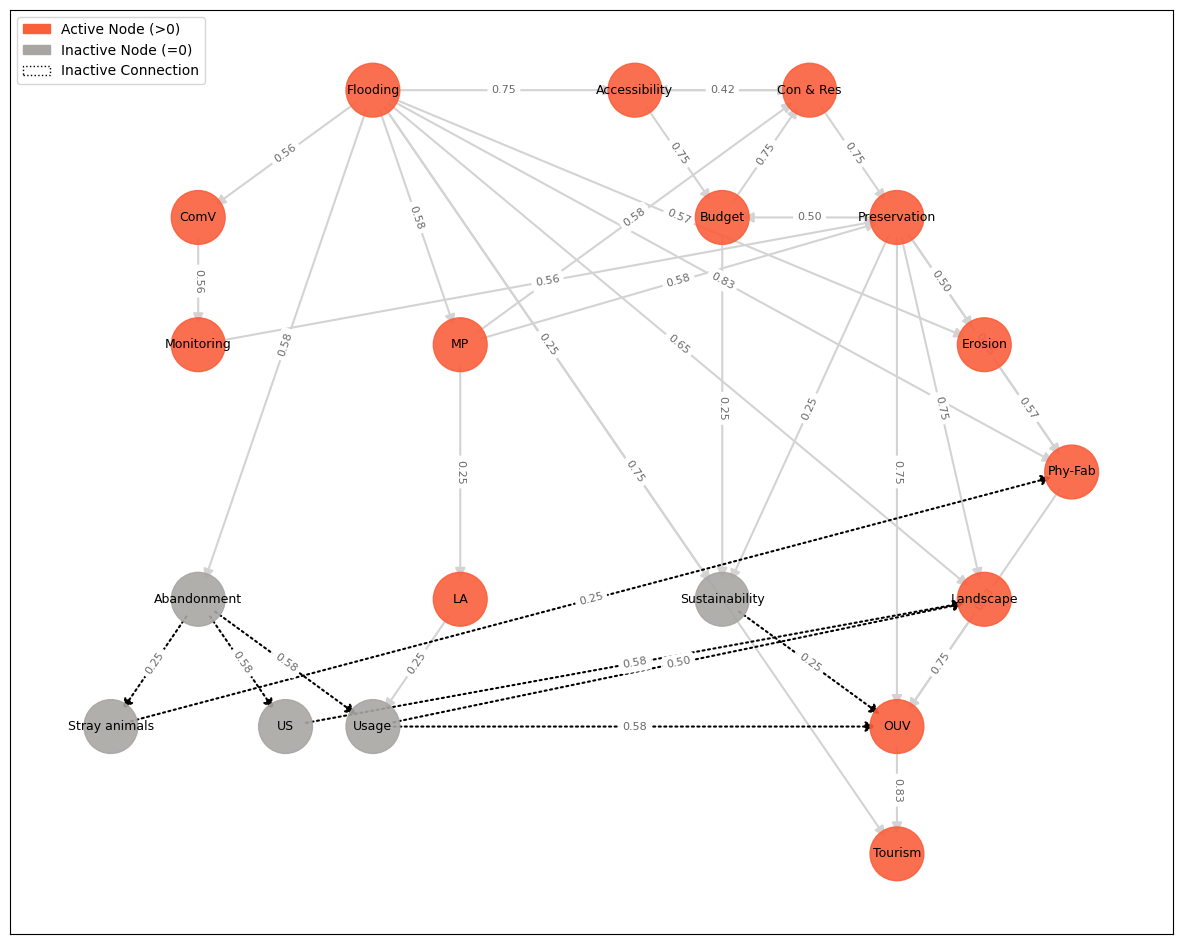

In [3]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.patches as mpatches
import os

# Bridge concepts with activation values
bridge_concepts = {
    "LA": 0.421, "OUV": 0.700, "Abandonment": 0.000, "Accessibility": 0.200,
    "Erosion": 0.548, "Landscape": 0.425, "Preservation": 0.25, "MP": 0.637,
    "Monitoring": 0.404, "Stray animals": 0.000, "US": 0.000, "ComV": 0.200,
    "Sustainability": 0.000, "Phy-Fab": 0.422, "Con & Res": 0.25,
    "Budget": 0.503, "Usage": 0.000
}

# Weighted edges
edges = [
    ("Flooding", "Landscape", 0.65), ("Landscape", "OUV", 0.75),
    ("OUV", "Tourism", 0.833), ("Flooding", "Tourism", 0.75),
    ("Flooding", "Erosion", 0.571), ("Erosion", "Phy-Fab", 0.571),
    ("Phy-Fab", "OUV", 0.833), ("Flooding", "Accessibility", 0.75),
    ("Accessibility", "Con & Res", 0.75), ("Con & Res", "Preservation", 0.75),
    ("Preservation", "Budget", 0.5), ("Budget", "Sustainability", 0.25),
    ("Sustainability", "OUV", 0.25), ("Preservation", "Landscape", 0.75),
    ("Preservation", "Sustainability", 0.25), ("Preservation", "Erosion", 0.5),
    ("Preservation", "Phy-Fab", 0.75), ("Accessibility", "Budget", 0.75),
    ("Flooding", "Phy-Fab", 0.833), ("Flooding", "MP", 0.583),
    ("MP", "Con & Res", 0.583), ("MP", "Preservation", 0.583),
    ("Preservation", "OUV", 0.75), ("Flooding", "Abandonment", 0.583),
    ("Abandonment", "Usage", 0.583), ("Usage", "OUV", 0.583),
    ("Usage", "Landscape", 0.5), ("ComV", "Monitoring", 0.562),
    ("Monitoring", "Preservation", 0.562), ("Budget", "Con & Res", 0.75),
    ("Con & Res", "Accessibility", 0.417), ("Abandonment", "US", 0.583),
    ("US", "Landscape", 0.583), ("Abandonment", "Stray animals", 0.25),
    ("Stray animals", "Phy-Fab", 0.25), ("MP", "LA", 0.25),
    ("LA", "Usage", 0.25), ("Flooding", "ComV", 0.562),
    ("Flooding", "Sustainability", 0.25)
]

# Build graph
G = nx.DiGraph()
for src, tgt, w in edges:
    G.add_edge(src, tgt, weight=w)

for node, activation in bridge_concepts.items():
    if node in G.nodes:
        G.nodes[node]["activation"] = activation

G.add_node("Flooding", activation=1.0)
G.add_node("Tourism", activation=0.8)

# Manually adjusted node positions to match the uploaded image
pos = {
    "Flooding": (-1.5, 2.5), "ComV": (-2.5, 2), "Monitoring": (-2.5, 1.5),
    "Abandonment": (-2.5, 0.5), "Stray animals": (-3, 0), "US": (-2, 0),
    "Usage": (-1.5, 0), "LA": (-1, 0.5), "MP": (-1, 1.5), "Accessibility": (0, 2.5),
    "Budget": (0.5, 2), "Con & Res": (1, 2.5), "Preservation": (1.5, 2),
    "Erosion": (2, 1.5), "Phy-Fab": (2.5, 1), "Landscape": (2, 0.5),
    "OUV": (1.5, 0), "Sustainability": (0.5, 0.5), "Tourism": (1.5, -0.5)
}

# Node colors
node_colors = ["#fa5f3c" if G.nodes[n].get("activation", 0) > 0 else "#a8a6a3" for n in G.nodes]


# Edge styles
active_edges = []
inactive_edges = []
edge_labels = {}

for u, v, data in G.edges(data=True):
    weight = data.get("weight", 0)
    edge_labels[(u, v)] = f"{weight:.2f}"
    if G.nodes[u].get("activation", 0) == 0:
        inactive_edges.append((u, v))
    else:
        active_edges.append((u, v))

# Draw network
plt.figure(figsize=(15, 12))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1500, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=9, font_color="black")

nx.draw_networkx_edges(
    G, pos, edgelist=active_edges, edge_color="lightgray",
    arrows=True, arrowsize=15, width=1.5, connectionstyle="arc3,rad=0",
    min_source_margin=15, min_target_margin=15
)

nx.draw_networkx_edges(
    G, pos, edgelist=inactive_edges, edge_color="black", style="dotted",
    arrows=True, arrowsize=15, width=1.5, connectionstyle="arc3,rad=0",
    min_source_margin=15, min_target_margin=15
)

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, font_color="dimgray")

# Legend
active_patch = mpatches.Patch(color="#fa5f3c", label="Active Node (>0)")
inactive_patch = mpatches.Patch(color="#a8a6a3", label="Inactive Node (=0)")
inactive_edge_patch = mpatches.Patch(edgecolor="black", facecolor="none", linestyle=":", label="Inactive Connection")

plt.legend(handles=[active_patch, inactive_patch, inactive_edge_patch], loc="upper left")
plt.title("", fontsize=14)

# Save and show
output_folder = "Analysis and output folders"
os.makedirs(output_folder, exist_ok=True)
output_path = os.path.join(output_folder, "Flooding_to_Tourism_matched_positions.png")
plt.savefig(output_path, dpi=600, bbox_inches="tight")
plt.show()

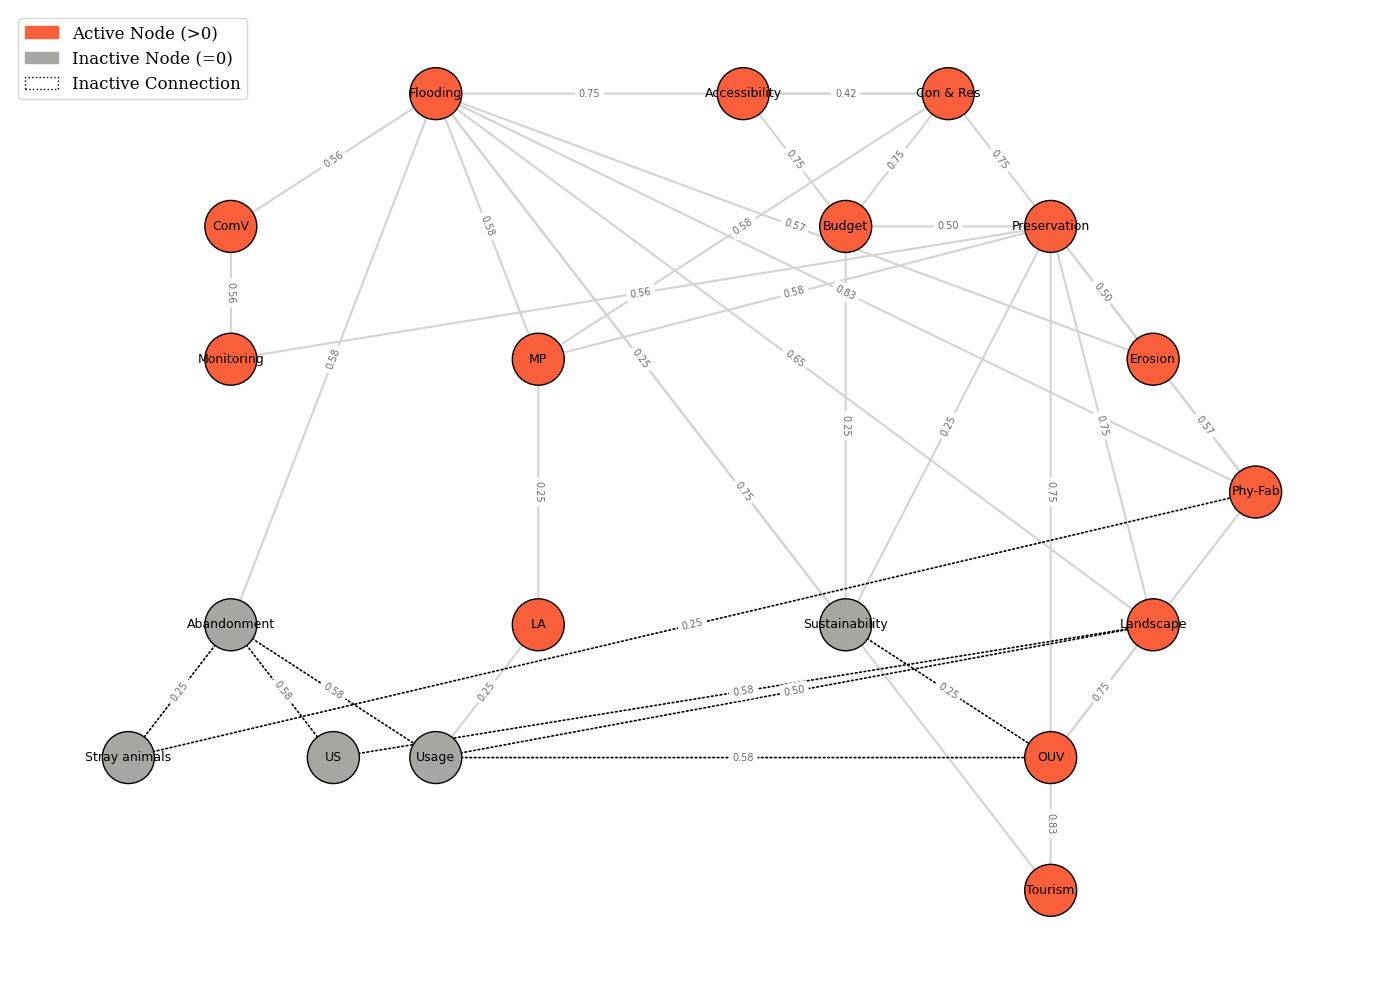

In [4]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.patches as mpatches
import os

# =========================
# GLOBAL PUBLICATION STYLE
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 14
})

# =========================
# OUTPUT FOLDER
# =========================
output_folder = "Results"
os.makedirs(output_folder, exist_ok=True)

# =========================
# Bridge concepts with activation values
# =========================
bridge_concepts = {
    "LA": 0.421, "OUV": 0.700, "Abandonment": 0.000, "Accessibility": 0.200,
    "Erosion": 0.548, "Landscape": 0.425, "Preservation": 0.25, "MP": 0.637,
    "Monitoring": 0.404, "Stray animals": 0.000, "US": 0.000, "ComV": 0.200,
    "Sustainability": 0.000, "Phy-Fab": 0.422, "Con & Res": 0.25,
    "Budget": 0.503, "Usage": 0.000
}

# =========================
# Weighted edges
# =========================
edges = [
    ("Flooding", "Landscape", 0.65), ("Landscape", "OUV", 0.75),
    ("OUV", "Tourism", 0.833), ("Flooding", "Tourism", 0.75),
    ("Flooding", "Erosion", 0.571), ("Erosion", "Phy-Fab", 0.571),
    ("Phy-Fab", "OUV", 0.833), ("Flooding", "Accessibility", 0.75),
    ("Accessibility", "Con & Res", 0.75), ("Con & Res", "Preservation", 0.75),
    ("Preservation", "Budget", 0.5), ("Budget", "Sustainability", 0.25),
    ("Sustainability", "OUV", 0.25), ("Preservation", "Landscape", 0.75),
    ("Preservation", "Sustainability", 0.25), ("Preservation", "Erosion", 0.5),
    ("Preservation", "Phy-Fab", 0.75), ("Accessibility", "Budget", 0.75),
    ("Flooding", "Phy-Fab", 0.833), ("Flooding", "MP", 0.583),
    ("MP", "Con & Res", 0.583), ("MP", "Preservation", 0.583),
    ("Preservation", "OUV", 0.75), ("Flooding", "Abandonment", 0.583),
    ("Abandonment", "Usage", 0.583), ("Usage", "OUV", 0.583),
    ("Usage", "Landscape", 0.5), ("ComV", "Monitoring", 0.562),
    ("Monitoring", "Preservation", 0.562), ("Budget", "Con & Res", 0.75),
    ("Con & Res", "Accessibility", 0.417), ("Abandonment", "US", 0.583),
    ("US", "Landscape", 0.583), ("Abandonment", "Stray animals", 0.25),
    ("Stray animals", "Phy-Fab", 0.25), ("MP", "LA", 0.25),
    ("LA", "Usage", 0.25), ("Flooding", "ComV", 0.562),
    ("Flooding", "Sustainability", 0.25)
]

# =========================
# Build graph
# =========================
G = nx.DiGraph()
for src, tgt, w in edges:
    G.add_edge(src, tgt, weight=w)

for node, activation in bridge_concepts.items():
    if node in G.nodes:
        G.nodes[node]["activation"] = activation

G.add_node("Flooding", activation=1.0)
G.add_node("Tourism", activation=0.8)

# =========================
# Node positions
# =========================
pos = {
    "Flooding": (-1.5, 2.5), "ComV": (-2.5, 2), "Monitoring": (-2.5, 1.5),
    "Abandonment": (-2.5, 0.5), "Stray animals": (-3, 0), "US": (-2, 0),
    "Usage": (-1.5, 0), "LA": (-1, 0.5), "MP": (-1, 1.5), "Accessibility": (0, 2.5),
    "Budget": (0.5, 2), "Con & Res": (1, 2.5), "Preservation": (1.5, 2),
    "Erosion": (2, 1.5), "Phy-Fab": (2.5, 1), "Landscape": (2, 0.5),
    "OUV": (1.5, 0), "Sustainability": (0.5, 0.5), "Tourism": (1.5, -0.5)
}

# =========================
# Node colors
# =========================
node_colors = [
    "#fa5f3c" if G.nodes[n].get("activation", 0) > 0 else "#a8a6a3"
    for n in G.nodes
]

# =========================
# Edge styles
# =========================
active_edges = []
inactive_edges = []
edge_labels = {}

for u, v, data in G.edges(data=True):
    weight = data.get("weight", 0)
    edge_labels[(u, v)] = f"{weight:.2f}"
    if G.nodes[u].get("activation", 0) == 0:
        inactive_edges.append((u, v))
    else:
        active_edges.append((u, v))

# =========================
# Plot
# =========================
plt.figure(figsize=(14, 10))

nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=1400,
    edgecolors="black"
)

nx.draw_networkx_labels(
    G, pos,
    font_size=9,
    font_color="black"
)

# Active edges
nx.draw_networkx_edges(
    G, pos,
    edgelist=active_edges,
    edge_color="lightgray",
    arrows=True,
    arrowsize=14,
    width=1.5
)

# Inactive edges
nx.draw_networkx_edges(
    G, pos,
    edgelist=inactive_edges,
    edge_color="black",
    style="dotted",
    arrows=True,
    arrowsize=14,
    width=1.2
)

nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_size=7,
    font_color="dimgray"
)

# =========================
# Legend
# =========================
active_patch = mpatches.Patch(color="#fa5f3c", label="Active Node (>0)")
inactive_patch = mpatches.Patch(color="#a8a6a3", label="Inactive Node (=0)")
inactive_edge_patch = mpatches.Patch(
    edgecolor="black",
    facecolor="none",
    linestyle=":",
    label="Inactive Connection"
)

plt.legend(handles=[active_patch, inactive_patch, inactive_edge_patch], loc="upper left")

plt.axis("off")
plt.tight_layout()

# =========================
# Save figure
# =========================
png_path = os.path.join(output_folder, "Flooding_Tourism_Network.png")
pdf_path = os.path.join(output_folder, "Flooding_Tourism_Network.pdf")

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")

plt.show()